## 1. Kirjastot ja datan lataus

Ladataan käytettävä aineisto käyttämällä `cimlrepo`:n tarjoamaa `fetch_ucirepo` metodia sekä luodaan kopio sen sisältämästä datasta

In [1]:
# Tarvittaessa:
# %pip install ucimlrepo

import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import math

chronic_kidney_disease = fetch_ucirepo(id=336)

X = chronic_kidney_disease.data.features.copy()
y = chronic_kidney_disease.data.targets.copy()

print(chronic_kidney_disease.variables)


     name     role         type demographic              description  \
0     age  Feature      Integer         Age                      NaN   
1      bp  Feature      Integer         NaN           blood pressure   
2      sg  Feature  Categorical         NaN         specific gravity   
3      al  Feature  Categorical         NaN                  albumin   
4      su  Feature  Categorical         NaN                    sugar   
5     rbc  Feature       Binary         NaN          red blood cells   
6      pc  Feature       Binary         NaN                 pus cell   
7     pcc  Feature       Binary         NaN          pus cell clumps   
8      ba  Feature       Binary         NaN                 bacteria   
9     bgr  Feature      Integer         NaN     blood glucose random   
10     bu  Feature      Integer         NaN               blood urea   
11     sc  Feature   Continuous         NaN         serum creatinine   
12    sod  Feature      Integer         NaN                   so

## 2. Datan yhdistäminen ja sarakkeiden valinta

Yhdistetään kaksi lähdemateriaalista saatua taulukkoa jossa toisessa arvot ja toisessa luokka (ckd ja notckd), lisäksi tiputetaan ylimääräiset sarakkeet ja uudelleen nimetään jäljelle jäävät selkokielisiksi

In [2]:
df = pd.concat([X, y], axis=1)

columns_to_drop = [
    "rbc", "pc", "pcc", "ba", "sc",
    "htn", "dm", "cad", "appet", "pe", "ane"
]
df = df.drop(columns=columns_to_drop)

long_column_names = {
    "bp": "blood pressure",
    "sg": "specific gravity",
    "al": "albumin",
    "su": "sugar",
    "bgr": "blood glucose random",
    "bu": "blood urea",
    "sod": "sodium",
    "pot": "potassium",
    "hemo": "hemoglobin",
    "pcv": "packed cell volume",
    "wbcc": "white blood cell count",
    "rbcc": "red blood cell count",
}
df = df.rename(columns=long_column_names)

print(df.columns)
print(df.shape)
df.head()

Index(['age', 'blood pressure', 'specific gravity', 'albumin', 'sugar',
       'blood glucose random', 'blood urea', 'sodium', 'potassium',
       'hemoglobin', 'packed cell volume', 'white blood cell count',
       'red blood cell count', 'class'],
      dtype='str')
(400, 14)


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,15.4,44.0,7800.0,5.2,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,11.3,38.0,6000.0,NaN,ckd
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,9.6,31.0,7500.0,NaN,ckd
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,11.2,32.0,6700.0,3.9,ckd
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,11.6,35.0,7300.0,4.6,ckd


## 3. Luokan (`class`) arvojen siivous

Uniikkeja arvoja katsoessa huomataan että `ckd` ja `notckd` arvojen seassa on `ckd\t`, oletettavasti kyseessä ylimääräinen tab joten siivotaan pois sekä nimetään 
- `ckd` → `a` = affected
- `notckd` → `c` = control

In [3]:
print("Class values before:", df["class"].unique())

df["class"] = df["class"].replace({
    "ckd\t": "a",
    "ckd": "a",
    "notckd": "c"
})

print("Class values after:", df["class"].unique())


Class values before: <ArrowStringArray>
['ckd', 'ckd\t', 'notckd']
Length: 3, dtype: str
Class values after: <ArrowStringArray>
['a', 'c']
Length: 2, dtype: str


## 4. Hemoglobiinin yksikön muunnos

Muutetaan hemoglobiiniarvot yksiköstä g/dl yksikköön g/l kertomalla arvot kymmenellä. 


In [4]:
df["hemoglobin"] = df["hemoglobin"] * 10
df["hemoglobin"].head()


0    154.0
1    113.0
2     96.0
3    112.0
4    116.0
Name: hemoglobin, dtype: float64

## 5. Puuttuvien arvojen perusteella poistettavat rivit

Poistetaan rivit jossa 3 tai enemmän NaN-arvoa

In [5]:
print("Rows before:", len(df))

missing_per_row = df.isna().sum(axis=1)
df = df[missing_per_row < 3].copy()

print("Rows after:", len(df))


Rows before: 400
Rows after: 265


## 6. Jako affected- ja control-ryhmiin

Jaetaan data luokan perusteella kahtia

In [13]:
df_affected = df[df["class"] == "a"].copy()
df_control = df[df["class"] == "c"].copy()

print(f"Affected individuals: {len(df_affected)}")
print(f"Control individuals: {len(df_control)}")
print(f"Total: {len(df_affected) + len(df_control)}")

assert len(df) == len(df_affected) + len(df_control)

print(f"Affected individuals: {len(df_affected)}")
display(df_affected)

print(f"Control individuals: {len(df_control)}")
display(df_control)


Affected individuals: 126
Control individuals: 139
Total: 265
Affected individuals: 126


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.0,3.2,122.0,39.0,7800.0,4.4,a
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.0,4.0,124.0,36.0,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,62.0,90.0,1.020,2.0,1.0,169.0,48.0,138.0,2.9,134.0,47.0,11000.0,6.1,a
244,64.0,90.0,1.015,3.0,2.0,463.0,64.0,135.0,4.1,122.0,40.0,9800.0,4.6,a
246,48.0,110.0,1.015,3.0,0.0,106.0,215.0,120.0,5.7,86.0,26.0,5000.0,2.5,a
248,59.0,70.0,1.010,1.0,3.0,424.0,55.0,138.0,4.5,126.0,37.0,10200.0,4.1,a


Control individuals: 139


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
250,40.0,80.0,1.025,0.0,0.0,140.0,10.0,135.0,5.0,150.0,48.0,10400.0,4.5,c
251,23.0,80.0,1.025,0.0,0.0,70.0,36.0,150.0,4.6,170.0,52.0,9800.0,5.0,c
252,45.0,80.0,1.025,0.0,0.0,82.0,49.0,147.0,4.4,159.0,46.0,9100.0,4.7,c
253,57.0,80.0,1.025,0.0,0.0,119.0,17.0,135.0,4.7,154.0,42.0,6200.0,6.2,c
254,51.0,60.0,1.025,0.0,0.0,99.0,38.0,135.0,3.7,130.0,49.0,8300.0,5.2,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


## 7. Jäljelle jäävien NaN-arvojen käsittely

Korvataan jäljelle jäävät NaN arvot saman ryhmän keskiarvoilla

In [7]:
numeric_columns = df.select_dtypes(include="number").columns

df_affected[numeric_columns] = df_affected[numeric_columns].fillna(
    df_affected[numeric_columns].mean()
)

df_control[numeric_columns] = df_control[numeric_columns].fillna(
    df_control[numeric_columns].mean()
)

print("Remaining NaNs in affected:")
print(df_affected.isna().sum())

print("\nRemaining NaNs in control:")
print(df_control.isna().sum())


Remaining NaNs in affected:
age                       0
blood pressure            0
specific gravity          0
albumin                   0
sugar                     0
blood glucose random      0
blood urea                0
sodium                    0
potassium                 0
hemoglobin                0
packed cell volume        0
white blood cell count    0
red blood cell count      0
class                     0
dtype: int64

Remaining NaNs in control:
age                       0
blood pressure            0
specific gravity          0
albumin                   0
sugar                     0
blood glucose random      0
blood urea                0
sodium                    0
potassium                 0
hemoglobin                0
packed cell volume        0
white blood cell count    0
red blood cell count      0
class                     0
dtype: int64


## 8. Perustilastot

Lasketaan tilasto arvot `describe()` metodilla. Johon kuuluu mm. keskiarvo, mediaani, minimi, maksimi, keskihajonta ja prosentti

In [8]:
display(df_affected.describe(include="all"))
display(df_control.describe(include="all"))


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126
mean,57.081301,80.720000,1.013560,1.849206,0.809524,181.200000,80.420000,133.731481,4.751852,106.432000,32.440000,9450.442478,3.976852,NaN
std,14.290469,15.706101,0.004508,1.437038,1.366539,91.276599,60.258855,7.093215,3.889174,21.808745,7.122247,3521.684231,0.781343,NaN
min,6.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,104.000000,2.500000,31.000000,9.000000,2600.000000,2.100000,NaN
25%,50.000000,70.000000,1.010000,0.250000,0.000000,108.250000,37.500000,132.000000,3.925000,95.250000,29.000000,7325.000000,3.500000,NaN
50%,60.000000,80.000000,1.015000,2.000000,0.000000,162.500000,60.000000,134.500000,4.400000,108.000000,32.720000,9450.442478,3.976852,NaN
75%,65.000000,90.000000,1.015000,3.000000,1.000000,238.750000,106.750000,138.000000,4.800000,120.000000,37.000000,10650.000000,4.300000,NaN


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
count,139.000000,139.000000,139.000000,139.0,139.0,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,139
mean,46.568345,71.313869,1.022482,0.0,0.0,107.385185,32.874074,141.735294,4.335294,151.883212,46.246377,7708.088235,5.380882,NaN
std,15.903719,8.497017,0.002509,0.0,0.0,18.474026,11.314624,4.739956,0.589833,12.751849,4.092785,1795.326265,0.586505,NaN
min,12.000000,60.000000,1.020000,0.0,0.0,70.000000,10.000000,135.000000,3.300000,130.000000,40.000000,4300.000000,4.500000,NaN
25%,34.000000,60.000000,1.020000,0.0,0.0,93.500000,24.000000,138.000000,3.700000,141.000000,43.000000,6300.000000,4.900000,NaN
50%,46.000000,70.000000,1.020000,0.0,0.0,107.385185,32.874074,141.735294,4.500000,150.000000,46.000000,7500.000000,5.300000,NaN
75%,58.000000,80.000000,1.025000,0.0,0.0,123.000000,44.000000,145.500000,4.900000,161.500000,50.000000,9200.000000,5.900000,NaN


## 9. Histogrammit

Luodaan kaikille numeerisille sarakkeille histogrammi matplotlib kirjastolla.

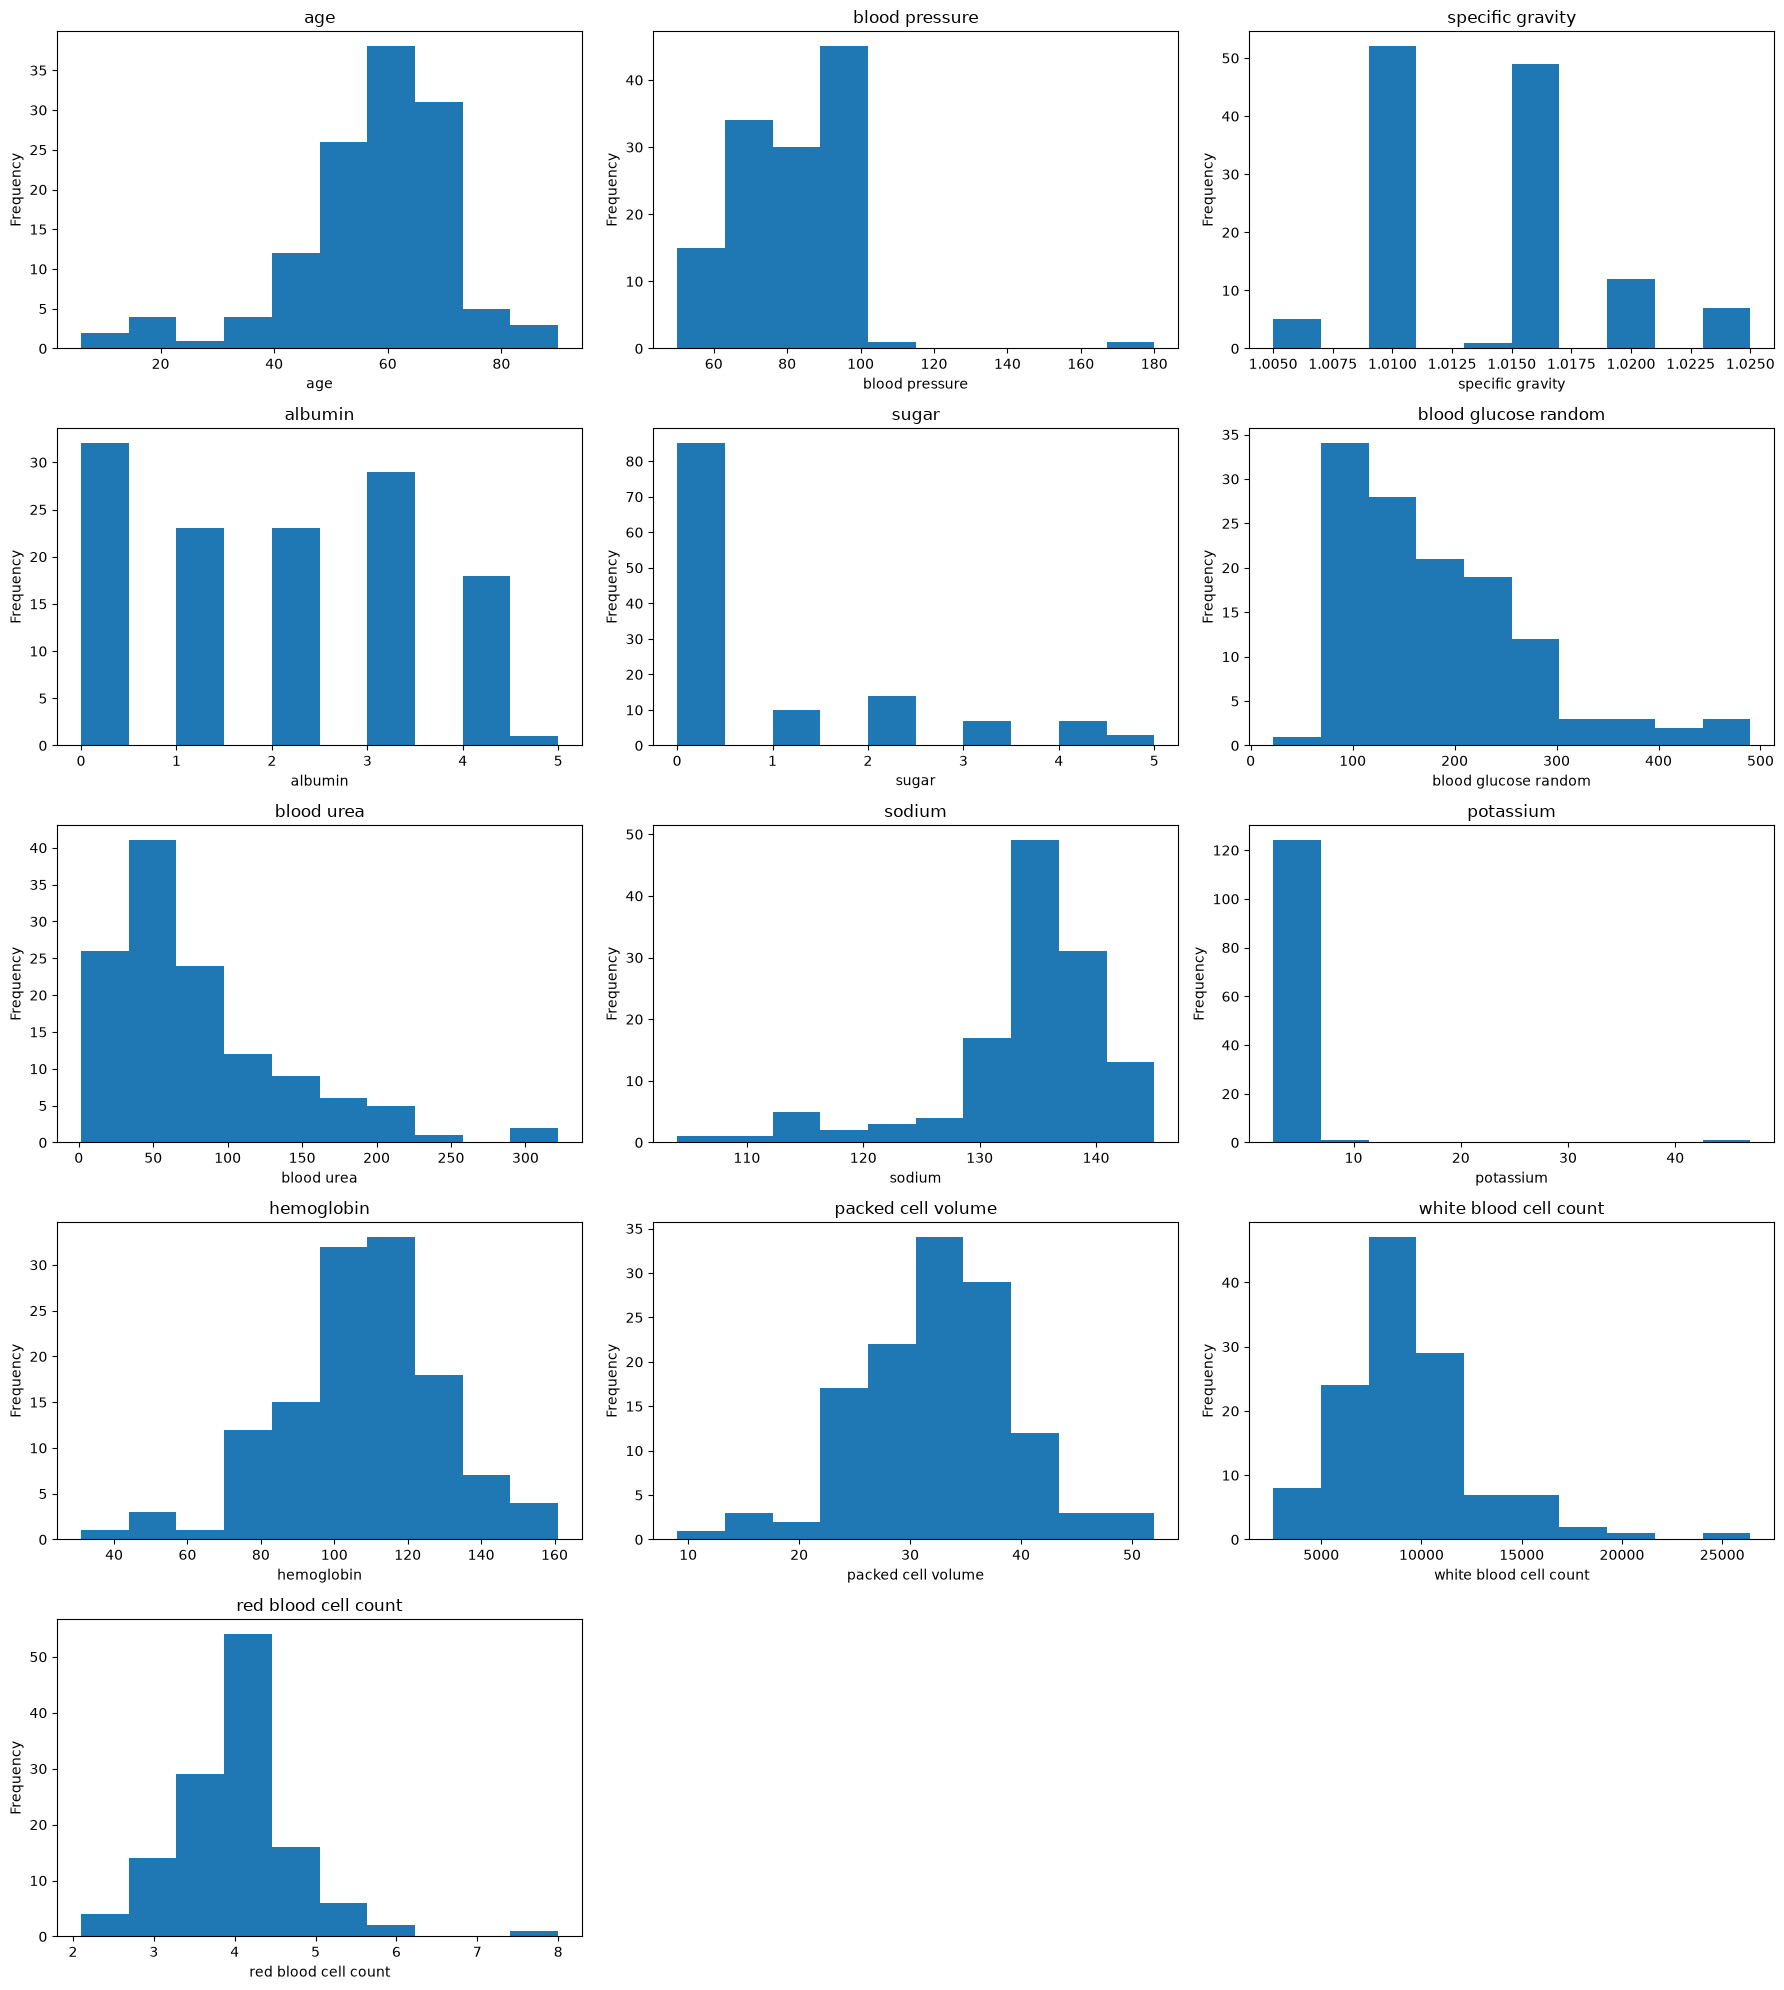

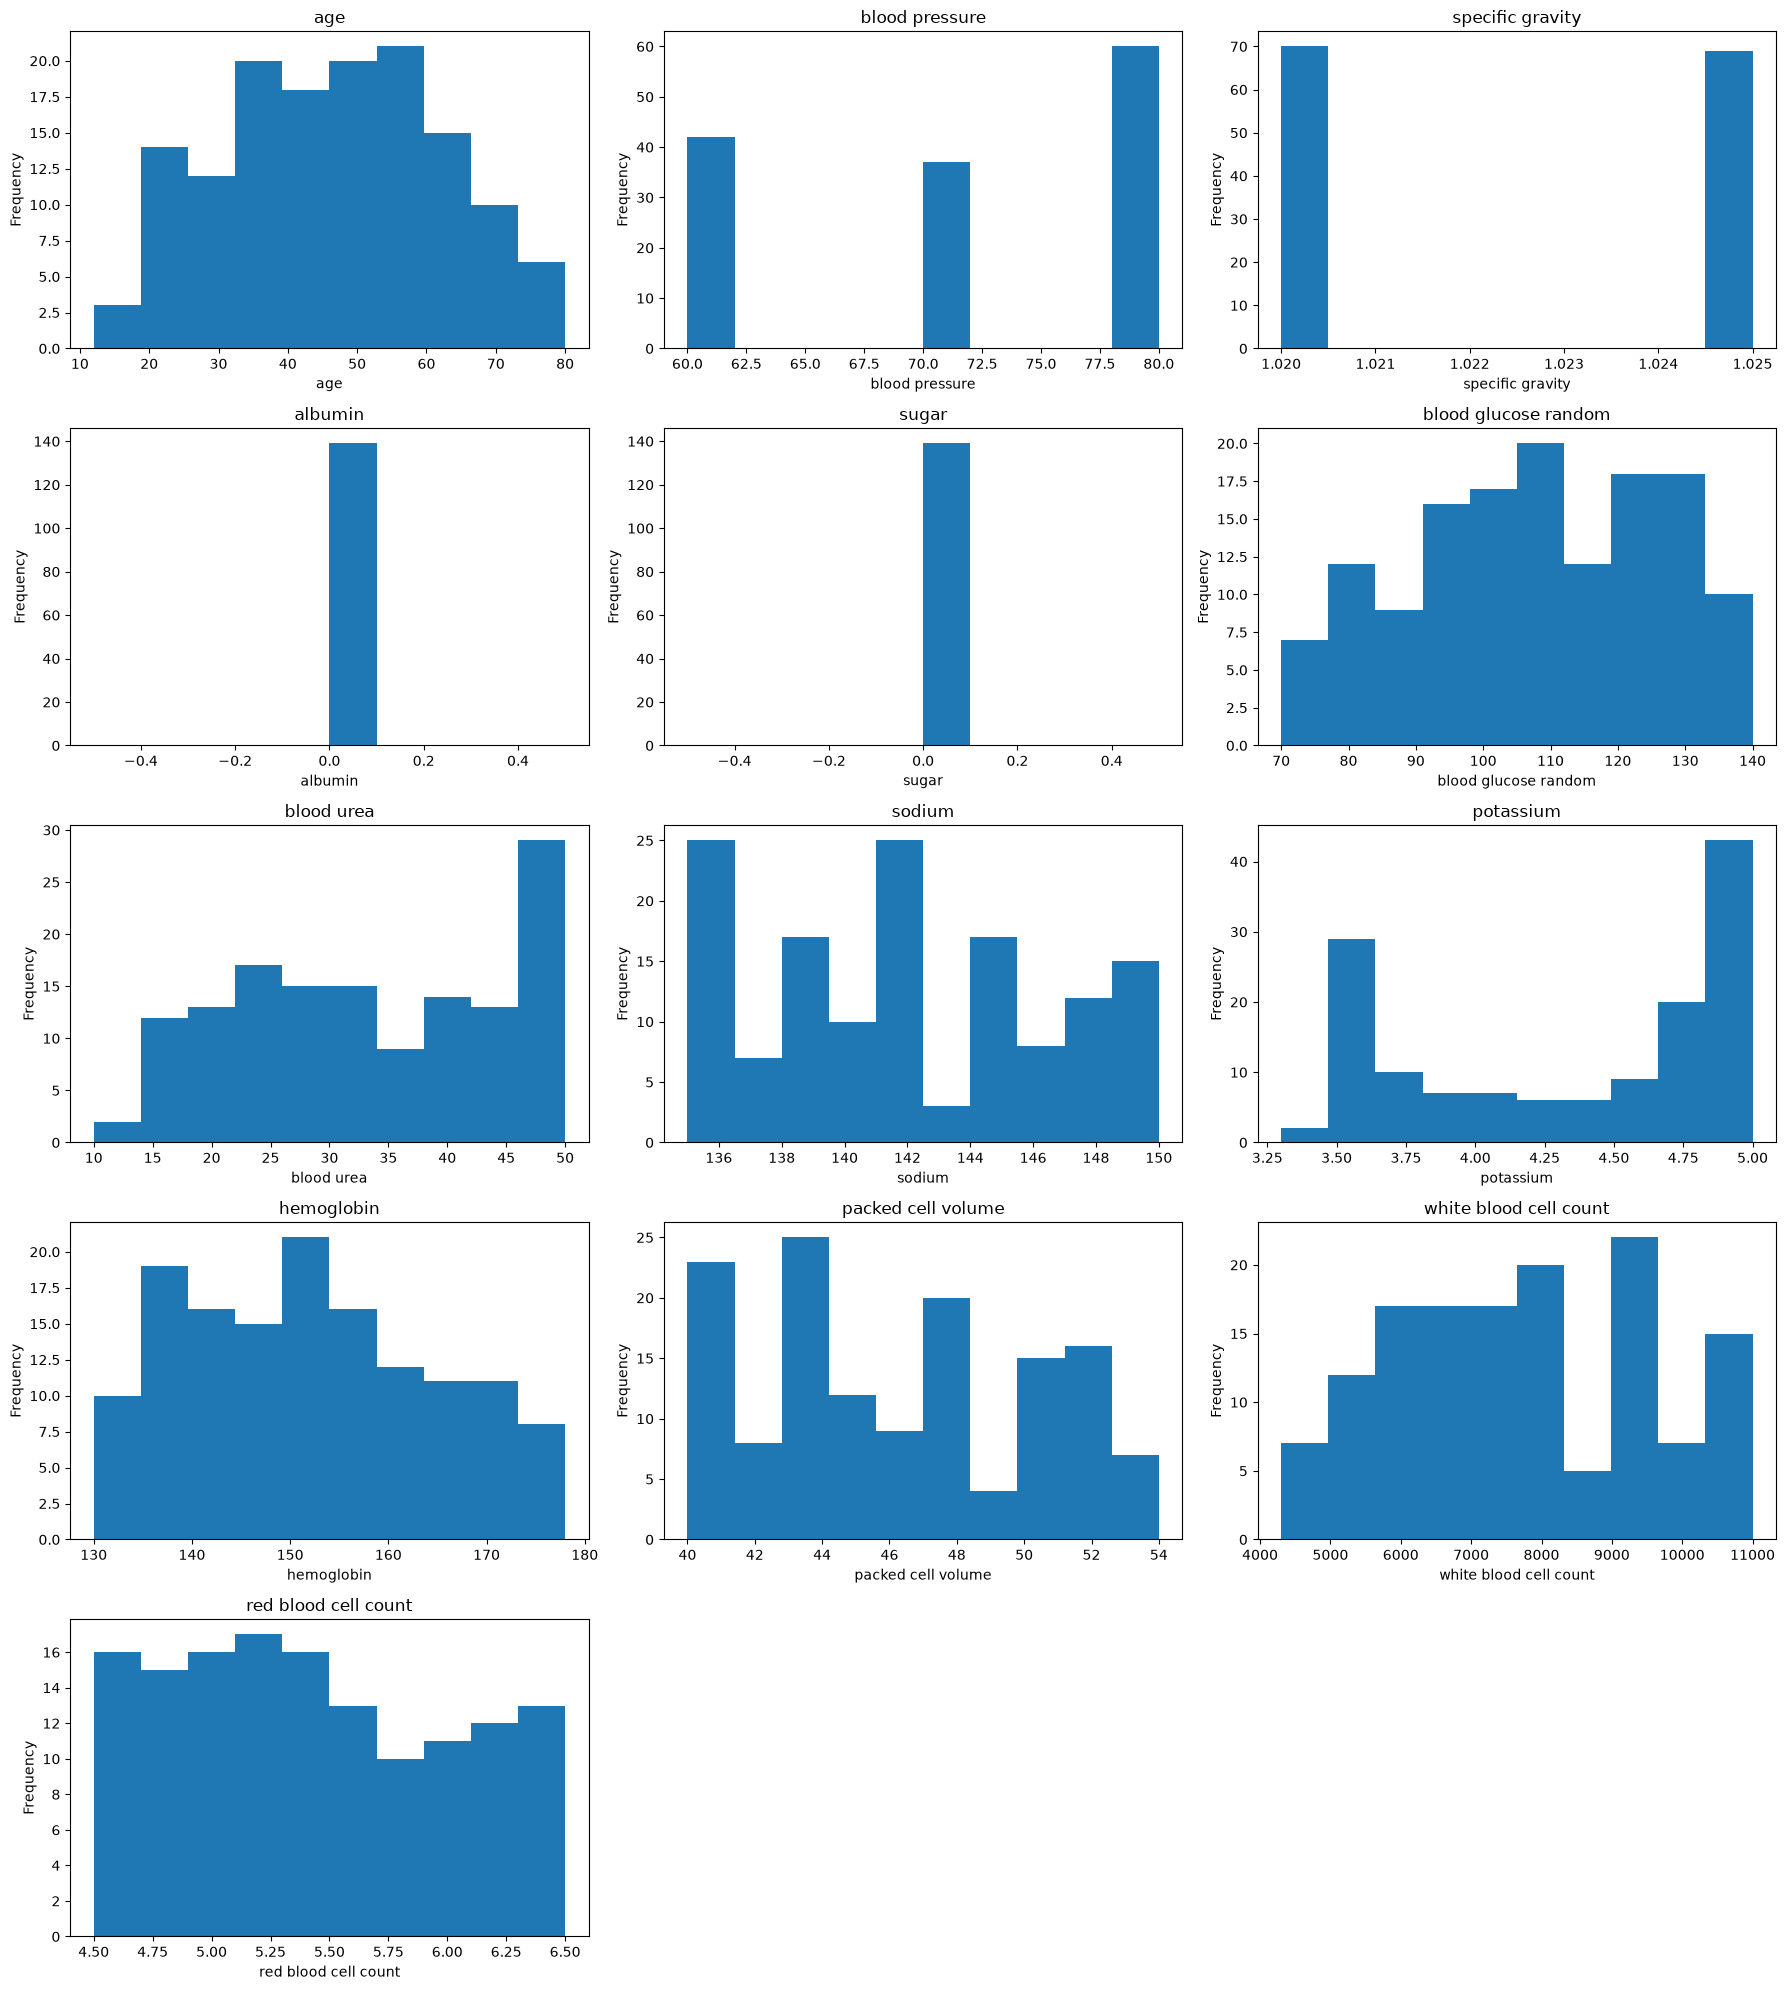

In [9]:
def plot_data(dataframe):
    numeric = dataframe.select_dtypes(include="number").columns
    ncols = 3
    nrows = math.ceil(len(numeric) / ncols)

    plt.figure(figsize=(18, 4 * nrows))
    for i, col in enumerate(numeric):
        plt.subplot(nrows, ncols, i + 1)
        dataframe[col].plot(kind="hist", title=col)
        plt.xlabel(col)

    plt.tight_layout()
    plt.show()

plot_data(df_affected)
plot_data(df_control)


## 10. Poikkeavat arvot

Saaduista histogrammeista näemme joitain poikkeuksellisia arvoja, korvataan ne ryhmien keskiarvoilla seuraavien ehtojen perusteella
- `bp >= 120` koska muiden arvojen perusteella on diastolinen verenpaine kyseessä jolloin yli 120 on hengenvaarallinen
- `pot >= 20` yksi yksittäine arvo löytyi tosi suurena joten tämän datan mukaan järkevä raja olisi 20
- `wbcc > 26000` yksi yksittäine arvo löytyi tosi suurena joten tämän datan mukaan järkevä raja olisi 20


In [10]:
def replace_outliers_with_group_mean(group):
    group = group.copy()

    group["blood pressure"] = group["blood pressure"].where(
        group["blood pressure"] < 120,
        group["blood pressure"].mean()
    )

    group["potassium"] = group["potassium"].where(
        group["potassium"] < 20,
        group["potassium"].mean()
    )

    group["white blood cell count"] = group["white blood cell count"].where(
        group["white blood cell count"] <= 26000,
        group["white blood cell count"].mean()
    )

    return group


df_affected = replace_outliers_with_group_mean(df_affected)
df_control = replace_outliers_with_group_mean(df_control)

print("Outlier replacement applied:")
print("- bp >= 120")
print("- pot >= 20")
print("- wbcc > 26000")


Outlier replacement applied:
- bp >= 120
- pot >= 20
- wbcc > 26000


## 11. Korrelaatiot

Lasketaan molemmille korrelaatiomatriisit ja plotataan ne pyplotilla heatmapiksi

In [11]:
corr_affected = df_affected.drop(columns=["class"]).corr()
corr_control = df_control.drop(columns=["class"]).corr()

display(corr_affected)
display(corr_control)


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
age,1.000000,0.076154,-0.004819,-0.016571,0.138345,0.198776,0.022488,-0.032251,0.107531,-0.005994,-0.043052,0.011189,-0.014509
blood pressure,0.076154,1.000000,0.066779,0.105836,0.076879,-0.029228,0.135540,0.127177,0.117920,-0.130731,-0.120194,-0.137133,0.089747
specific gravity,-0.004819,0.066779,1.000000,-0.061097,-0.043993,-0.080525,-0.037699,0.135620,0.073917,0.113712,0.106540,-0.089232,0.114892
albumin,-0.016571,0.105836,-0.061097,1.000000,0.115618,0.095670,0.426955,-0.168165,0.162448,-0.368770,-0.327130,0.007015,-0.218082
sugar,0.138345,0.076879,-0.043993,0.115618,1.000000,0.670732,-0.053433,0.047624,-0.000095,0.184665,0.120105,0.073976,0.088578
blood glucose random,0.198776,-0.029228,-0.080525,0.095670,0.670732,1.000000,-0.026117,-0.049332,-0.097443,0.136368,0.091705,0.018059,0.128597
blood urea,0.022488,0.135540,-0.037699,0.426955,-0.053433,-0.026117,1.000000,-0.303788,0.292985,-0.605467,-0.565864,-0.118836,-0.469732
sodium,-0.032251,0.127177,0.135620,-0.168165,0.047624,-0.049332,-0.303788,1.000000,0.053490,0.260854,0.280209,-0.001837,0.218154
potassium,0.107531,0.117920,0.073917,0.162448,-0.000095,-0.097443,0.292985,0.053490,1.000000,-0.299902,-0.306205,-0.228632,-0.229447
hemoglobin,-0.005994,-0.130731,0.113712,-0.368770,0.184665,0.136368,-0.605467,0.260854,-0.299902,1.000000,0.951500,0.064965,0.702853


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
age,1.000000,-0.070944,-0.092814,NaN,NaN,0.097586,0.075247,0.109060,-0.093062,0.055630,-0.009895,0.126629,-0.044371
blood pressure,-0.070944,1.000000,0.083860,NaN,NaN,0.004235,-0.082011,-0.104416,-0.063618,0.157085,-0.007767,-0.096849,-0.030481
specific gravity,-0.092814,0.083860,1.000000,NaN,NaN,-0.037851,-0.049379,-0.033513,0.073449,0.026113,-0.007057,-0.027750,0.066479
albumin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sugar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood glucose random,0.097586,0.004235,-0.037851,NaN,NaN,1.000000,-0.067624,-0.007712,0.145166,-0.146072,-0.253887,-0.067189,-0.192723
blood urea,0.075247,-0.082011,-0.049379,NaN,NaN,-0.067624,1.000000,0.005469,0.046601,0.084880,0.114665,0.040241,-0.010640
sodium,0.109060,-0.104416,-0.033513,NaN,NaN,-0.007712,0.005469,1.000000,0.065758,-0.010508,-0.001545,0.334073,-0.091558
potassium,-0.093062,-0.063618,0.073449,NaN,NaN,0.145166,0.046601,0.065758,1.000000,0.095812,-0.165237,0.040684,-0.052106
hemoglobin,0.055630,0.157085,0.026113,NaN,NaN,-0.146072,0.084880,-0.010508,0.095812,1.000000,0.057216,-0.187561,0.073083


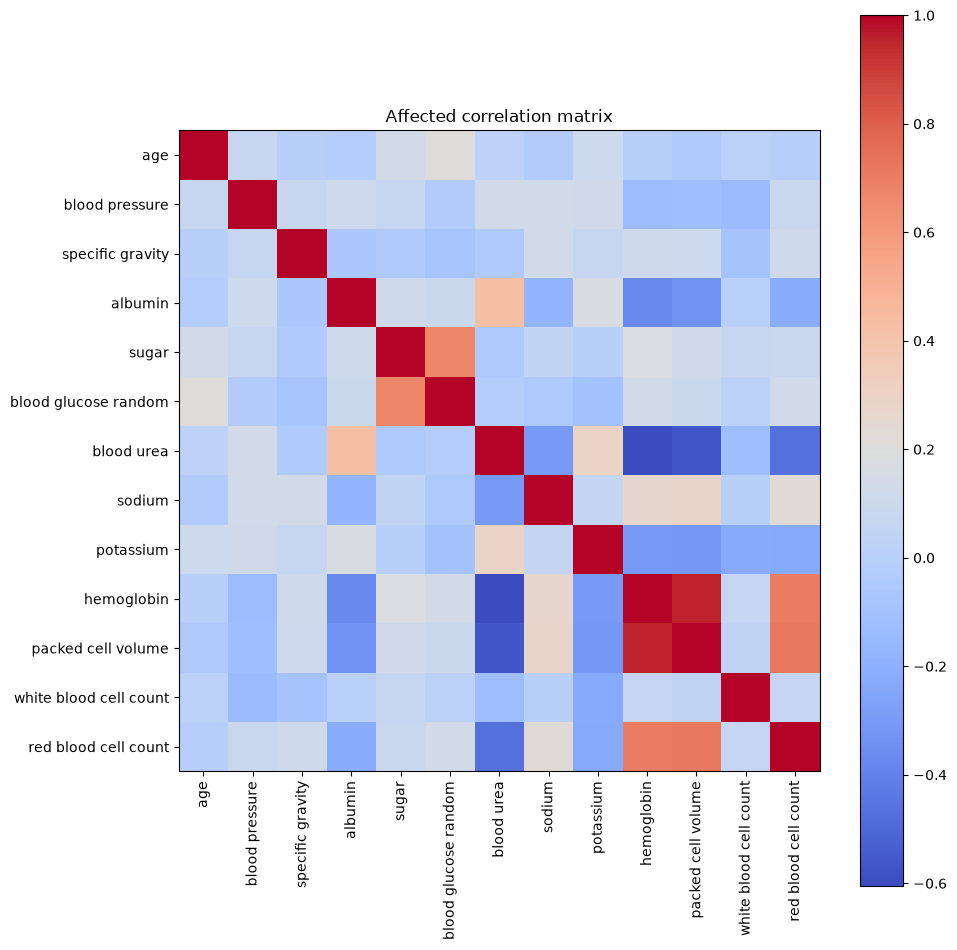

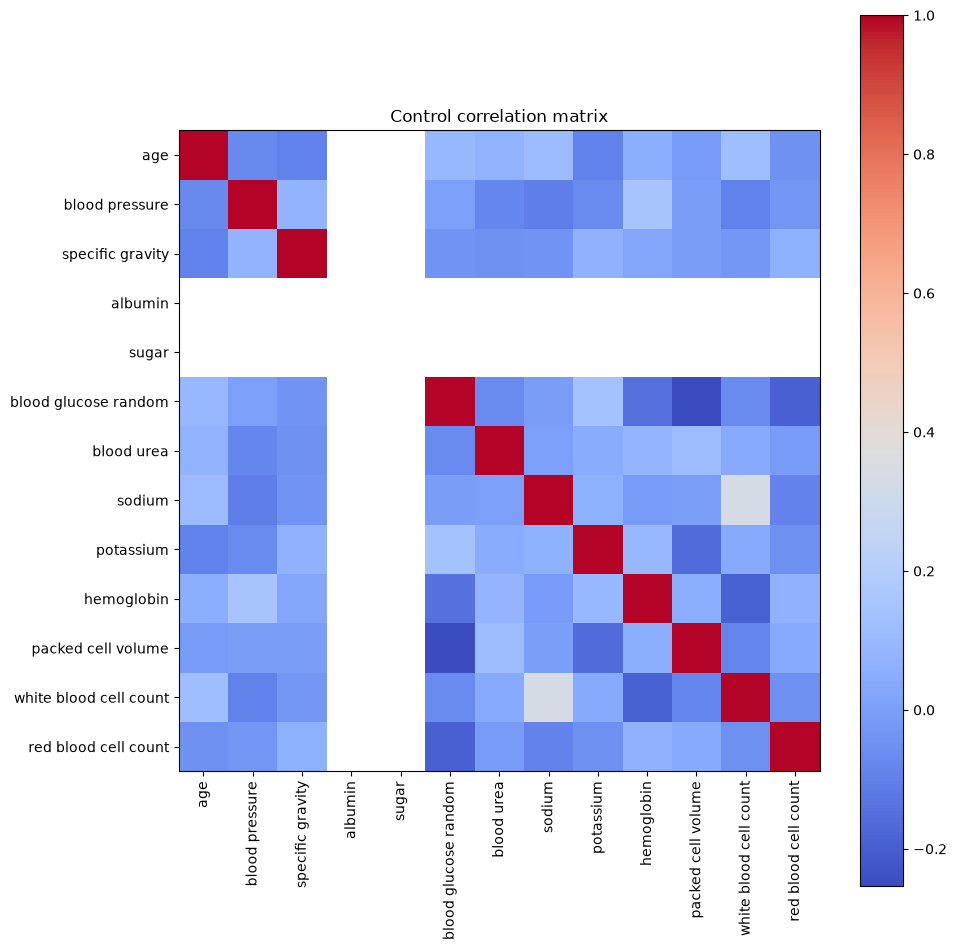

In [12]:
def plot_correlation(corr, title):
    plt.figure(figsize=(10, 10))
    plt.imshow(corr, cmap="coolwarm", interpolation="none")
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=90)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_correlation(corr_affected, "Affected correlation matrix")
plot_correlation(corr_control, "Control correlation matrix")


## 12. Tulkinta
Kontrolliryhmän albumiini- ja sokeriarvoissa ei ole vaihtelua (arvot ovat 0), minkä vuoksi niiden korrelaatiota muiden muuttujien kanssa ei voida määrittää ja korrelaatiomatriisissa näkyy NaN-arvoja.

Korrelaatiomatriisi osoittaa korrelaation sairastuneiden potilaiden seuraavien muuttujien välillä:
- punasolujen määrä ja hemoglobiini
- hematokriitti (packed cell volume) ja hemoglobiini
- hematokriitti ja punasolujen määrä
- albumiini ja veren urea

  -> tämä voi viitata munuaisten toimintahäiriöön tai krooniseen tulehdukseen, koska albumiinin kaltaisia suuria molekyylejä erittyy virtsaan.
- satunnainen verensokeri (random blood glucose) ja virtsan sokeri välillä

  -> tämä viittaa yleensä diabetekseen, mutta munuaisten toimintahäiriö voi myös vaikuttaa siihen, että sokeria erittyy virtsaan.

Näiden arvojen perusteella pystytään suhteellisen tarkkaa ennustamaan onko potilaalla krooninen munuaissairaus. 